# Notebook 2 — Correlation analysis

Notebook 1 built our dataset. Before we touch it, this notebook has two parts:

- **Part A** builds up what "correlation" actually means and how it's calculated, step by step, using tiny toy examples that have nothing to do with sales.
- **Part B** applies that understanding to `sales_activity_data.csv` — computing, for each activity, how strongly it correlates with revenue, and comparing high-vs-low activity groups.

We deliberately do **not** open `ground_truth.json` in this notebook. Everything here is what a real analyst would see with only the public dataset in hand.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", rc={"grid.color": "#e6e5e0", "axes.edgecolor": "#c9c8c0"})

ACCENT = "#2a78d6"     # single hue, used when color carries no extra meaning
POSITIVE = "#2a78d6"   # blue = positive correlation
NEGATIVE = "#e34948"   # red = negative correlation
NEUTRAL = "#9a9990"    # gray = ~zero / no relationship
LOW_GROUP = "#eb6834"  # orange = "low activity" segment
HIGH_GROUP = "#2a78d6" # blue = "high activity" segment

DATA_DIR = Path("../data")
rng = np.random.default_rng(2026)  # local RNG for this notebook's toy examples only

## Part A — What does "correlation" mean?

Two variables are correlated when they tend to move together: as one goes up, the other tends to go up too (**positive**), tends to go down (**negative**), or shows no consistent pattern at all (**no correlation**). Before any formula, here's what those three cases actually look like.

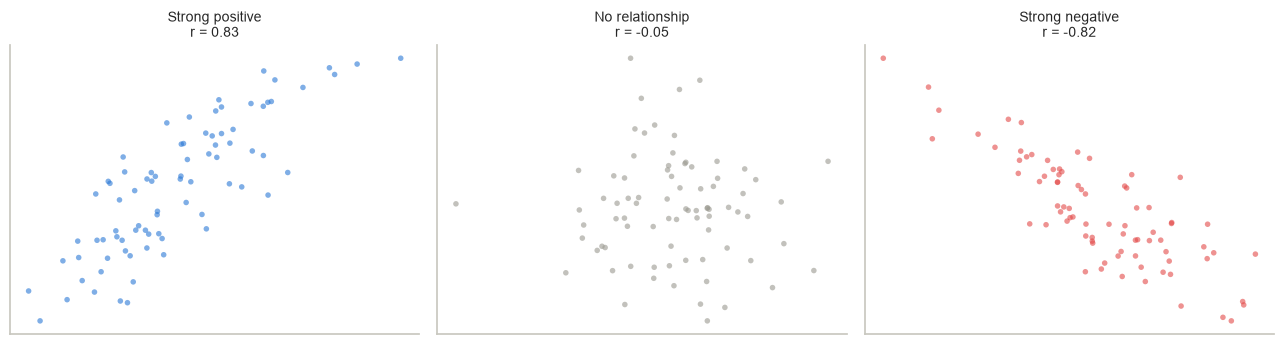

In [2]:
def correlated_xy(target_r, n=80, rng=rng):
    """Generate x, y with (approximately) the given Pearson correlation."""
    x = rng.normal(0, 1, n)
    z = rng.normal(0, 1, n)
    y = target_r * x + np.sqrt(1 - target_r**2) * z
    return x, y

examples = [("Strong positive", 0.85, POSITIVE), ("No relationship", 0.0, NEUTRAL), ("Strong negative", -0.85, NEGATIVE)]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, (label, target_r, color) in zip(axes, examples):
    x, y = correlated_xy(target_r)
    actual_r = stats.pearsonr(x, y).statistic
    ax.scatter(x, y, s=16, alpha=0.6, color=color, edgecolor="none")
    ax.set_title(f"{label}\nr = {actual_r:.2f}", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

## Building Pearson's r by hand

We'll use a tiny, unrelated toy example — 10 students' study hours vs. their exam scores — so every step of the arithmetic fits on one screen.

The idea behind Pearson's r: for each point, look at how far x is from the *average* x, and how far y is from the *average* y.
- If a point is above-average on both (or below-average on both), that pair of deviations multiplies to a **positive** number.
- If one is above-average and the other below-average, it multiplies to a **negative** number.

Add up those products across all points: if positive and negative pairs cancel out, there's no consistent pattern (~0). If most points agree in direction, the sum is large in magnitude. Dividing by the spread of x and y (their standard deviations) rescales that sum into the fixed range **[-1, +1]**, so it means the same thing regardless of the units x and y happen to be measured in.

In [3]:
study_hours = np.array([1, 2, 3, 4, 4, 5, 6, 7, 8, 9])
exam_score = np.array([54.0, 59.8, 60.4, 60.7, 63.3, 64.1, 74.4, 86.0, 79.0, 82.3])

steps = pd.DataFrame({
    "hours (x)": study_hours,
    "score (y)": exam_score,
})
steps["dx = x - mean(x)"] = steps["hours (x)"] - steps["hours (x)"].mean()
steps["dy = y - mean(y)"] = steps["score (y)"] - steps["score (y)"].mean()
steps["dx * dy"] = steps["dx = x - mean(x)"] * steps["dy = y - mean(y)"]
steps["dx^2"] = steps["dx = x - mean(x)"] ** 2
steps["dy^2"] = steps["dy = y - mean(y)"] ** 2
steps

,hours (x),score (y),dx = x - mean(x),dy = y - mean(y),dx * dy,dx^2,dy^2
0,1,54.0,-3.9,-14.4,56.16,15.21,207.36
1,2,59.8,-2.9,-8.6,24.94,8.41,73.96
2,3,60.4,-1.9,-8.0,15.20,3.61,64.00
3,4,60.7,-0.9,-7.7,6.93,0.81,59.29
4,4,63.3,-0.9,-5.1,4.59,0.81,26.01
5,5,64.1,0.1,-4.3,-0.43,0.01,18.49
6,6,74.4,1.1,6.0,6.60,1.21,36.00
7,7,86.0,2.1,17.6,36.96,4.41,309.76
8,8,79.0,3.1,10.6,32.86,9.61,112.36
9,9,82.3,4.1,13.9,56.99,16.81,193.21


In [4]:
numerator = steps["dx * dy"].sum()
denominator = np.sqrt(steps["dx^2"].sum() * steps["dy^2"].sum())
r_by_hand = numerator / denominator

r_scipy = stats.pearsonr(study_hours, exam_score).statistic

print(f"sum(dx * dy)        = {numerator:.2f}")
print(f"sqrt(sum(dx^2) * sum(dy^2)) = {denominator:.2f}")
print(f"r (by hand)          = {r_by_hand:.4f}")
print(f"r (scipy.pearsonr)   = {r_scipy:.4f}")

sum(dx * dy)        = 240.80
sqrt(sum(dx^2) * sum(dy^2)) = 258.88
r (by hand)          = 0.9302
r (scipy.pearsonr)   = 0.9302


## Is r = 0.93 real, or could 10 students just get lucky? (p-values, step by step)

We only have 10 students. Even if study hours had **zero** real effect on scores, pairing 10 random hours with 10 random scores could, by pure luck, land on something that looks like a strong correlation.

So here's the question a p-value actually answers: *if there were truly no relationship, how often would we see a correlation this strong just by chance?* We can answer that directly, by simulating "truly no relationship" ourselves — shuffle which score belongs to which student's hours (this destroys any real link between them, since the pairing becomes random), recompute r, and repeat thousands of times. That gives us the full range of r values pure chance can produce with 10 students.

**Concretely, before doing this 5,000 times:** the 10 students and their hours/score numbers never change. What changes is *which score gets attached to which student's hours* — we randomly reshuffle the same 10 scores, breaking any real link between them and hours.

In [5]:
example_shuffle = rng.permutation(exam_score)
example_r = stats.pearsonr(study_hours, example_shuffle).statistic

pd.DataFrame({
    "student": list("ABCDEFGHIJ"),
    "hours (unchanged)": study_hours,
    "real score": exam_score,
    "one random shuffle of score": example_shuffle,
})

,student,hours (unchanged),real score,one random shuffle of score
0,A,1,54.0,60.4
1,B,2,59.8,59.8
2,C,3,60.4,86.0
3,D,4,60.7,64.1
4,E,4,63.3,82.3
5,F,5,64.1,63.3
6,G,6,74.4,54.0
7,H,7,86.0,60.7
8,I,8,79.0,79.0
9,J,9,82.3,74.4


In [6]:
print(f"r for the real pairing        = {r_scipy:.4f}")
print(f"r for this one random shuffle = {example_r:.4f}")

r for the real pairing        = 0.9302
r for this one random shuffle = 0.1507


That's one shuffle. Now we do the same thing 5,000 times — each with a fresh random reordering of the same 10 scores — and collect all 5,000 resulting r values.

In [7]:
n_perms = 5000
observed_r = r_scipy  # 0.93, from the real pairing above

perm_rs = np.array([
    stats.pearsonr(study_hours, rng.permutation(exam_score)).statistic
    for _ in range(n_perms)
])
n_as_extreme = np.sum(np.abs(perm_rs) >= abs(observed_r))
p_perm = n_as_extreme / n_perms

pearson_full = stats.pearsonr(study_hours, exam_score)

print(f"observed r                = {observed_r:.4f}")
print(f"shuffles with |r| >= {abs(observed_r):.4f} = {n_as_extreme} out of {n_perms}")
print(f"permutation p-value       ≈ {p_perm:.4f}")
print(f"scipy's analytic p-value  = {pearson_full.pvalue:.6f}")

observed r                = 0.9302
shuffles with |r| >= 0.9302 = 0 out of 5000
permutation p-value       ≈ 0.0000
scipy's analytic p-value  = 0.000096


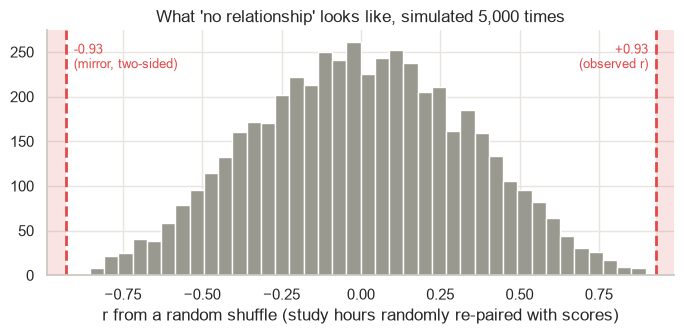

In [8]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(perm_rs, bins=40, color=NEUTRAL, edgecolor="white")

xmin, xmax = ax.get_xlim()
ymax = ax.get_ylim()[1]
ax.axvspan(observed_r, xmax, color=NEGATIVE, alpha=0.15, linewidth=0)
ax.axvspan(xmin, -observed_r, color=NEGATIVE, alpha=0.15, linewidth=0)
ax.axvline(observed_r, color=NEGATIVE, linewidth=2, linestyle="--")
ax.axvline(-observed_r, color=NEGATIVE, linewidth=2, linestyle="--")
ax.set_xlim(xmin, xmax)

# labels anchored to grow inward (toward the plot center), so they can't run off the figure edge
ax.text(observed_r, ymax * 0.95, f"+{observed_r:.2f}  \n(observed r)  ", color=NEGATIVE, fontsize=9, va="top", ha="right")
ax.text(-observed_r, ymax * 0.95, f"  -{observed_r:.2f}\n  (mirror, two-sided)", color=NEGATIVE, fontsize=9, va="top", ha="left")
ax.set_xlabel("r from a random shuffle (study hours randomly re-paired with scores)")
ax.set_title("What 'no relationship' looks like, simulated 5,000 times")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

Our real r = 0.93 sits out past almost every random shuffle — the shaded regions mark "as extreme as what we observed" **in either direction** (a shuffle landing at -0.93 would be just as surprising as one at +0.93, so both count), and almost nothing landed there. That's what a p-value is:

> **p-value = the fraction of "no relationship" simulations that produced a result at least as extreme as what we actually observed (in either direction, for a two-sided test).**

scipy doesn't run this simulation — it uses a formula (based on the t-distribution) that answers the same question analytically, which is why `scipy.stats.pearsonr` returns a p-value for free. Our simulated version and scipy's formula-based version agree, as they should.

**The 0.05 convention:** by convention (not a law of nature), if p < 0.05 — a result this extreme would happen less than 5% of the time under "no relationship" — we call it **statistically significant**. It's a common bar for "probably not just noise," not proof of a real, meaningful, or causal effect. Keep that number in mind — it's exactly what the next section is about to complicate.

## Interpreting r

r always falls in **[-1, +1]**. Rough, field-dependent guidelines: |r| < 0.3 weak, 0.3–0.6 moderate, > 0.6 strong. These bands aren't a law of nature — in noisy human-behavior data (like sales activity), even a "moderate" r can be a genuinely important effect. Here's what a range of r values actually looks like as a scatter, so the number and the shape connect.

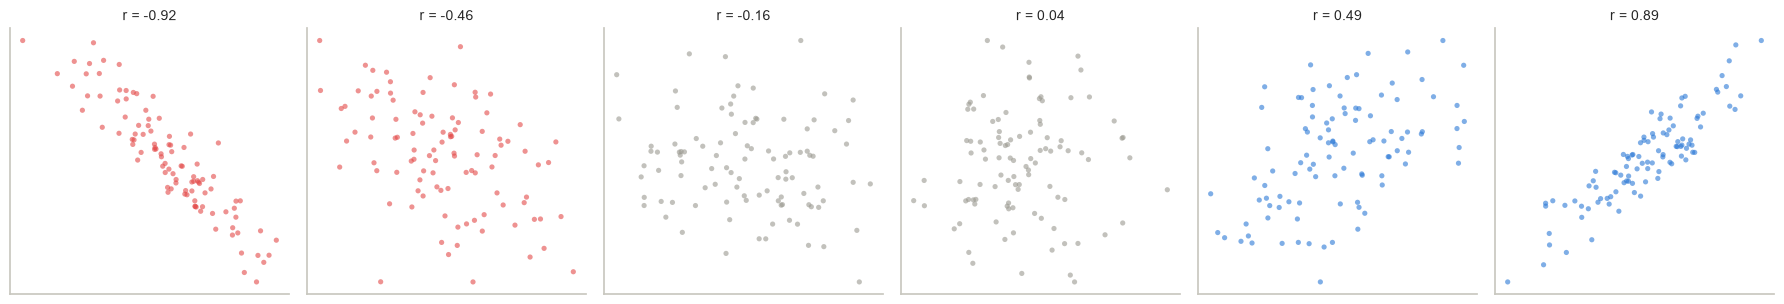

In [9]:
targets = [-0.9, -0.5, -0.15, 0.15, 0.5, 0.9]

fig, axes = plt.subplots(1, len(targets), figsize=(18, 3.2))
for ax, target_r in zip(axes, targets):
    x, y = correlated_xy(target_r, n=100)
    actual_r = stats.pearsonr(x, y).statistic
    color = POSITIVE if actual_r > 0.2 else NEGATIVE if actual_r < -0.2 else NEUTRAL
    ax.scatter(x, y, s=14, alpha=0.6, color=color, edgecolor="none")
    ax.set_title(f"r = {actual_r:.2f}", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

## Why Pearson isn't the only option

Pearson's r specifically measures **linear** agreement. Two situations break it:

**1. A real but curved (non-linear) relationship.** If y consistently increases as x increases, but the relationship curves rather than following a straight line, Pearson's r understates how strong the pattern actually is.

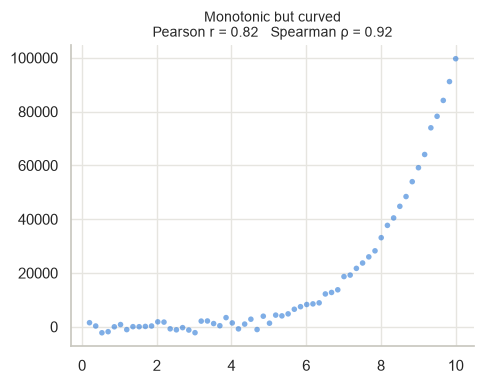

In [10]:
x_nl = np.linspace(0.2, 10, 60)
y_nl = x_nl**5
y_nl = y_nl + rng.normal(0, y_nl.std() * 0.05, len(x_nl))

pearson_nl = stats.pearsonr(x_nl, y_nl).statistic
spearman_nl = stats.spearmanr(x_nl, y_nl).statistic

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(x_nl, y_nl, s=16, alpha=0.6, color=POSITIVE, edgecolor="none")
ax.set_title(f"Monotonic but curved\nPearson r = {pearson_nl:.2f}   Spearman ρ = {spearman_nl:.2f}", fontsize=10)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

**2. Outliers.** Pearson's r uses raw deviations from the mean, so a couple of extreme points can dominate the sum and swing r a long way — even when the bulk of the data shows no relationship at all.

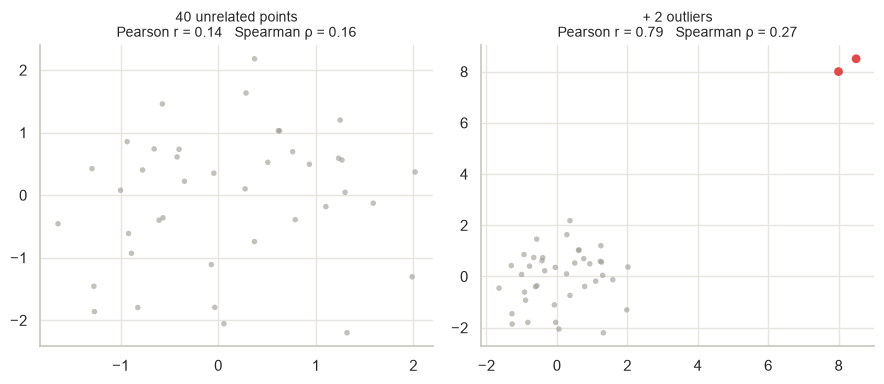

In [11]:
x_base = rng.normal(0, 1, 40)
y_base = rng.normal(0, 1, 40)  # genuinely unrelated

x_out = np.append(x_base, [8, 8.5])
y_out = np.append(y_base, [8, 8.5])

pearson_before = stats.pearsonr(x_base, y_base).statistic
spearman_before = stats.spearmanr(x_base, y_base).statistic
pearson_after = stats.pearsonr(x_out, y_out).statistic
spearman_after = stats.spearmanr(x_out, y_out).statistic

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].scatter(x_base, y_base, s=16, alpha=0.6, color=NEUTRAL, edgecolor="none")
axes[0].set_title(f"40 unrelated points\nPearson r = {pearson_before:.2f}   Spearman ρ = {spearman_before:.2f}", fontsize=10)
axes[1].scatter(x_out, y_out, s=16, alpha=0.6, color=NEUTRAL, edgecolor="none")
axes[1].scatter([8, 8.5], [8, 8.5], s=40, color=NEGATIVE, edgecolor="none")
axes[1].set_title(f"+ 2 outliers\nPearson r = {pearson_after:.2f}   Spearman ρ = {spearman_after:.2f}", fontsize=10)
for ax in axes:
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

## Spearman's rank correlation, step by step

Spearman's ρ fixes both problems above with one trick: **replace every value with its rank** (1st smallest, 2nd smallest, ...), then run the exact same Pearson formula on the ranks instead of the raw numbers. Ranking throws away *how much bigger* one point is than another and keeps only *which order* they come in — which is exactly why it shrugs off both curvature and outliers.

Let's do this by hand on the curved example from above.

In [12]:
rank_x = stats.rankdata(x_nl)
rank_y = stats.rankdata(y_nl)

# same Pearson formula as before, just applied to the ranks
rho_by_hand = stats.pearsonr(rank_x, rank_y).statistic
rho_scipy = stats.spearmanr(x_nl, y_nl).statistic

print("first 6 raw values:  x =", np.round(x_nl[:6], 2), " y =", np.round(y_nl[:6], 0))
print("first 6 ranks:       rank(x) =", rank_x[:6].astype(int), " rank(y) =", rank_y[:6].astype(int))
print()
print(f"Pearson r applied to the ranks = {rho_by_hand:.4f}")
print(f"scipy.stats.spearmanr           = {rho_scipy:.4f}")

first 6 raw values:  x = [0.2  0.37 0.53 0.7  0.86 1.03]  y = [ 1516.   287. -2228. -1824.    -5.   826.]
first 6 ranks:       rank(x) = [1 2 3 4 5 6]  rank(y) = [23 15  1  3 11 18]

Pearson r applied to the ranks = 0.9217
scipy.stats.spearmanr           = 0.9217


### A blind spot even Spearman has: non-monotonic relationships

The curved example above still had a consistent direction — y kept rising as x rose. That's exactly what Spearman needs: a consistent rank order, up or down, all the way through. If the relationship reverses direction partway, there's no consistent order left to find.

Points lying exactly on a circle make this obvious: x and y are perfectly, deterministically related (x² + y² = 1) — but as x sweeps from -1 to 1, y rises, then falls. No monotonic trend, so neither coefficient sees anything there.

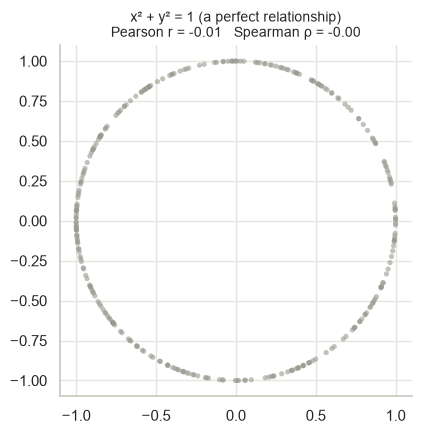

In [13]:
t = rng.uniform(0, 2 * np.pi, 300)
x_circle = np.cos(t)
y_circle = np.sin(t)

pearson_circle = stats.pearsonr(x_circle, y_circle).statistic
spearman_circle = stats.spearmanr(x_circle, y_circle).statistic

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.scatter(x_circle, y_circle, s=14, alpha=0.6, color=NEUTRAL, edgecolor="none")
ax.set_title(f"x² + y² = 1 (a perfect relationship)\nPearson r = {pearson_circle:.2f}   Spearman ρ = {spearman_circle:.2f}", fontsize=10)
ax.set_aspect("equal")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

Both coefficients report essentially zero, despite x and y being perfectly related — every point sits exactly on the circle. The takeaway: **a correlation near 0 means "no *linear or monotonic* relationship found," not "no relationship."** Detecting a shape like this needs a different tool (e.g. mutual information, distance correlation) or, most simply, just looking at the scatter plot — which is why we plot first and compute second throughout this notebook.

## One more case: correlation with a binary variable

Our dataset also has `quota_hit`, which is 0/1 rather than continuous. Correlating a continuous variable with a binary one is sometimes called "point-biserial correlation" — but it isn't a different formula to learn. It's just Pearson's r, computed as usual, where one of the two variables happens to only take values 0 and 1.

In [14]:
x_pb = rng.normal(50, 10, 60)
y_pb = (x_pb + rng.normal(0, 8, 60) > 52).astype(int)  # binary outcome, related to x_pb

pearson_pb = stats.pearsonr(x_pb, y_pb).statistic
pb = stats.pointbiserialr(y_pb, x_pb).statistic

print(f"pearsonr(x, binary_y)        = {pearson_pb:.4f}")
print(f"pointbiserialr(binary_y, x)  = {pb:.4f}   <- identical")

pearsonr(x, binary_y)        = 0.5632
pointbiserialr(binary_y, x)  = 0.5632   <- identical


## Part B — Applying this to the sales activity data

From here on, we work only with `sales_activity_data.csv` — the file a real analyst would actually have. No peeking at `ground_truth.json`.

In [15]:
df = pd.read_csv(DATA_DIR / "sales_activity_data.csv")
activity_cols = ["demos_given", "proposals_sent", "crm_usage", "calls_made", "training_completed"]
df.head()

,rep_id,territory_score,demos_given,proposals_sent,crm_usage,calls_made,training_completed,revenue,quota_hit
0,REP0001,5.6,5,1,10,33,1,34080.66,0
1,REP0002,2.9,1,4,1,27,1,20011.97,0
2,REP0003,6.5,8,3,21,25,3,47631.93,1
3,REP0004,6.9,3,4,13,17,0,36598.13,0
4,REP0005,1.1,7,4,0,25,1,28062.03,0


### Correlation of each activity with revenue

For each activity, we compute both Pearson r (linear) and Spearman ρ (monotonic, robust to outliers) against `revenue`, along with each one's p-value — same definition as in Part A, just computed by scipy's formula instead of by simulation this time.

In [16]:
rows = []
for col in activity_cols:
    pear = stats.pearsonr(df[col], df["revenue"])
    spear = stats.spearmanr(df[col], df["revenue"])
    rows.append({
        "activity": col,
        "pearson_r": pear.statistic,
        "pearson_p": pear.pvalue,
        "spearman_rho": spear.statistic,
        "spearman_p": spear.pvalue,
    })

corr_table = pd.DataFrame(rows).sort_values("pearson_r", key=abs, ascending=False).reset_index(drop=True)
corr_table

,activity,pearson_r,pearson_p,spearman_rho,spearman_p
0,crm_usage,0.610302,3.498339e-42,0.619703,8.508562e-44
1,proposals_sent,0.419147,1.892375e-18,0.373876,1.022162e-14
2,calls_made,0.406143,2.560032e-17,0.364752,4.946508e-14
3,demos_given,0.385986,1.165936e-15,0.352101,4.059400e-13
4,training_completed,0.034536,4.909695e-01,0.019495,6.974875e-01


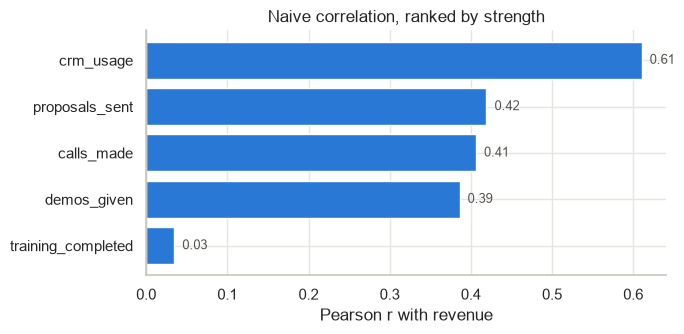

In [17]:
ranked = corr_table.sort_values("pearson_r", ascending=True)
colors = [POSITIVE if r >= 0 else NEGATIVE for r in ranked["pearson_r"]]

fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.barh(ranked["activity"], ranked["pearson_r"], color=colors)
for bar, r in zip(bars, ranked["pearson_r"]):
    ax.text(bar.get_width() + (0.01 if r >= 0 else -0.01), bar.get_y() + bar.get_height() / 2,
            f"{r:.2f}", va="center", ha="left" if r >= 0 else "right", fontsize=9, color="#52514e")
ax.axvline(0, color="#c9c8c0", linewidth=1)
ax.set_xlabel("Pearson r with revenue")
ax.set_title("Naive correlation, ranked by strength")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

### A caveat before trusting any of this: multiple comparisons

`crm_usage` looks like the strongest correlate of revenue. But we tested 5 activities at once, and the usual significance threshold (p < 0.05) is calibrated for testing **one** thing. Test enough unrelated things and some will look significant purely by chance.

Let's see this directly: generate 20 completely random, made-up "activities" — pure noise, unrelated to revenue by construction — and check how many clear p < 0.05 against real revenue anyway.

In [18]:
N_FAKE = 20
ALPHA = 0.05

fake_results = []
for i in range(N_FAKE):
    fake_activity = rng.normal(0, 1, len(df))  # pure noise, no connection to revenue whatsoever
    r, p = stats.pearsonr(fake_activity, df["revenue"])
    fake_results.append({"fake_activity": f"noise_{i+1}", "r": r, "p": p, "significant": p < ALPHA})

fake_table = pd.DataFrame(fake_results)
n_significant = fake_table["significant"].sum()

print(f"{n_significant} out of {N_FAKE} pure-noise 'activities' cleared p < {ALPHA} anyway.")
print(f"Expected by chance alone: {ALPHA} * {N_FAKE} = {ALPHA * N_FAKE:.1f}")
fake_table[fake_table["significant"]]

2 out of 20 pure-noise 'activities' cleared p < 0.05 anyway.
Expected by chance alone: 0.05 * 20 = 1.0


,fake_activity,r,p,significant
2,noise_3,-0.114367,0.022155,True
18,noise_19,0.112418,0.024547,True


### How risky is this, exactly, for our actual 5 tests?

The demo above ran 20 fake activities *once*. To see the real risk for our situation — testing 5 activities at once — we need a different question: if none of the 5 activities had any real effect, how often would **at least one** of the 5 still cross p < 0.05 just by chance?

We can simulate that directly: generate 5 fake, pure-noise activities and a fake, pure-noise "revenue," test all 5, and check whether *any* came back significant. Repeat that whole experiment thousands of times and count how often we got at least one false alarm.

**One trial, concretely, before we run 5,000:** generate 5 fake activities and 1 fake "revenue" — all pure noise, nothing related to anything else. Test each of the 5 fake activities against the fake revenue, exactly like we tested our 5 real activities against real revenue earlier. This single trial either produces zero significant results (the honest outcome, since nothing is really related) or, purely by chance, one or more "significant" results — a false alarm.

In [19]:
n_activities = len(activity_cols)  # 5, matching our real test
example_target = rng.normal(0, 1, len(df))  # one fake "revenue," pure noise

example_rows = []
for i in range(n_activities):
    fake_activity = rng.normal(0, 1, len(df))  # one fake activity, pure noise
    r, p = stats.pearsonr(fake_activity, example_target)
    example_rows.append({"fake_activity": f"fake_{i+1}", "r": r, "p": p, "significant (p < 0.05)": p < ALPHA})

example_trial = pd.DataFrame(example_rows)
example_trial

,fake_activity,r,p,significant (p < 0.05)
0,fake_1,0.107928,0.030918,True
1,fake_2,-0.023305,0.642140,False
2,fake_3,-0.061873,0.216914,False
3,fake_4,0.030353,0.544985,False
4,fake_5,-0.090957,0.069186,False


In [20]:
any_hit_this_trial = example_trial["significant (p < 0.05)"].any()
print(f"Did this one trial produce at least one false alarm among the {n_activities} fake activities?  {any_hit_this_trial}")

Did this one trial produce at least one false alarm among the 5 fake activities?  True


That's one trial — one "did any of the 5 fake activities falsely alarm?" coin flip, in effect. Run it once and you'll get True sometimes, False other times, depending on how the random numbers happened to fall. To find out how often it comes back True overall, we don't guess — we repeat the exact same trial 5,000 times and count.

In [21]:
n_trials = 5000
n_activities = len(activity_cols)  # 5, matching our real test
n_any_false_positive = 0

for _ in range(n_trials):
    fake_target = rng.normal(0, 1, len(df))  # stand-in for revenue, pure noise
    hit_this_trial = False
    for _ in range(n_activities):
        fake_activity = rng.normal(0, 1, len(df))  # stand-in for one activity, pure noise
        p = stats.pearsonr(fake_activity, fake_target).pvalue
        if p < ALPHA:
            hit_this_trial = True
    if hit_this_trial:
        n_any_false_positive += 1

empirical_rate = n_any_false_positive / n_trials
theoretical_rate = 1 - (1 - ALPHA) ** n_activities

print(f"At least one false alarm among {n_activities} tests, empirically: {empirical_rate:.3f}  ({n_any_false_positive} / {n_trials} trials)")
print(f"Theoretical:  1 - (1 - {ALPHA})^{n_activities} = {theoretical_rate:.3f}")

At least one false alarm among 5 tests, empirically: 0.233  (1164 / 5000 trials)
Theoretical:  1 - (1 - 0.05)^5 = 0.226


So instead of the 5% chance you'd expect from a single test, testing 5 activities at once gives roughly a **1-in-4 chance** that at least one comes back "significant" purely from randomness — even in a world where none of them have any real effect on revenue. That's the actual risk `crm_usage` clearing p < 0.05 is exposed to, just from the fact that we checked 5 things instead of 1.

The fix isn't complicated: when testing *k* things at once, tighten the significance bar (a simple version, the Bonferroni correction, uses α/k instead of α). For our 5 real activities, that's 0.05 / 5 = **0.01** — worth re-checking the table above against that stricter bar before taking any activity's correlation at face value.

### The other framing: high-activity vs. low-activity groups

Correlation coefficients are useful but abstract. The more intuitive, business-friendly version of the same question: "do reps with **high** use of an activity actually get better revenue than reps with **low** use of it?"

For each activity independently, we split reps into their bottom third and top third by that activity's level (dropping the middle third to sharpen the contrast), then compare revenue between the two groups:
- **Mann-Whitney U test** — a non-parametric test for "are these two groups' distributions different," robust to revenue's non-normal shape
- **Cohen's d** — how many standard deviations apart the two group means are; the effect size, not just a yes/no on significance

This is a different lens on the same relationship, not a new one — the reason to do both is that the group-comparison framing is often easier to explain to a non-technical audience than a correlation coefficient.

In [22]:
def cohens_d(a, b):
    n1, n2 = len(a), len(b)
    pooled_sd = np.sqrt(((n1 - 1) * a.var(ddof=1) + (n2 - 1) * b.var(ddof=1)) / (n1 + n2 - 2))
    return (a.mean() - b.mean()) / pooled_sd

group_rows = []
group_data = {}  # for the boxplots below
for col in activity_cols:
    low_cut, high_cut = df[col].quantile([1 / 3, 2 / 3])
    low_group = df.loc[df[col] <= low_cut, "revenue"]
    high_group = df.loc[df[col] >= high_cut, "revenue"]
    u_stat, p_val = stats.mannwhitneyu(high_group, low_group, alternative="two-sided")
    d = cohens_d(high_group, low_group)
    group_rows.append({
        "activity": col,
        "low_group_n": len(low_group),
        "high_group_n": len(high_group),
        "low_group_mean_revenue": low_group.mean(),
        "high_group_mean_revenue": high_group.mean(),
        "mannwhitney_p": p_val,
        "cohens_d": d,
    })
    group_data[col] = (low_group, high_group)

group_table = pd.DataFrame(group_rows).sort_values("cohens_d", ascending=False).reset_index(drop=True)
group_table

,activity,low_group_n,high_group_n,low_group_mean_revenue,high_group_mean_revenue,mannwhitney_p,cohens_d
0,crm_usage,148,155,32076.093581,46267.750581,5.425311e-28,1.481355
1,calls_made,142,140,34735.683310,43796.271571,3.045460e-11,0.860232
2,demos_given,178,150,35312.946910,43205.784600,1.004530e-09,0.737894
3,proposals_sent,182,218,35107.221923,42230.686101,2.332884e-10,0.685579
4,training_completed,186,214,38287.561075,39599.614953,4.039674e-01,0.119685


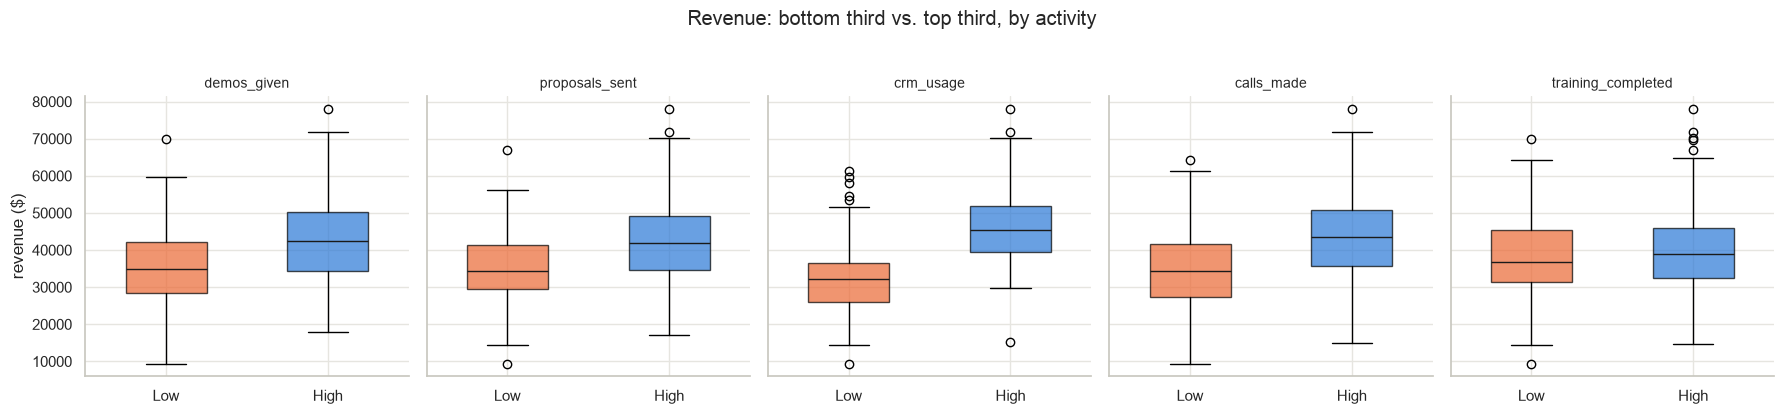

In [23]:
fig, axes = plt.subplots(1, len(activity_cols), figsize=(18, 4), sharey=True)
for ax, col in zip(axes, activity_cols):
    low_group, high_group = group_data[col]
    bp = ax.boxplot([low_group, high_group], tick_labels=["Low", "High"], patch_artist=True, widths=0.5)
    for patch, color in zip(bp["boxes"], [LOW_GROUP, HIGH_GROUP]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    for median in bp["medians"]:
        median.set_color("#1a1a19")
    ax.set_title(col, fontsize=10)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
axes[0].set_ylabel("revenue ($)")
fig.suptitle("Revenue: bottom third vs. top third, by activity", y=1.03)
plt.tight_layout()
plt.show()

## Leaderboard — and an important warning

Everything below is a legitimate summary of *association* in this data.

In [24]:
leaderboard = (
    corr_table[["activity", "pearson_r", "spearman_rho"]]
    .merge(group_table[["activity", "cohens_d", "mannwhitney_p"]], on="activity")
    .sort_values("pearson_r", key=abs, ascending=False)
    .reset_index(drop=True)
)
leaderboard

,activity,pearson_r,spearman_rho,cohens_d,mannwhitney_p
0,crm_usage,0.610302,0.619703,1.481355,5.425311e-28
1,proposals_sent,0.419147,0.373876,0.685579,2.332884e-10
2,calls_made,0.406143,0.364752,0.860232,3.045460e-11
3,demos_given,0.385986,0.352101,0.737894,1.004530e-09
4,training_completed,0.034536,0.019495,0.119685,4.039674e-01


**But none of it says why.** `crm_usage` ranking near the top could mean "logging more in the CRM helps reps sell" — or it could mean both `crm_usage` and revenue are driven by something else entirely (say, the quality of the territory a rep was handed), with no real link between the two at all. Correlation, on its own, cannot tell these apart.

That's exactly what notebook 3 does next: bring in `territory_score` and see which of today's correlations survive being controlled for it — and which ones shrink or vanish.